In [1]:
import torch
import matplotlib.pyplot as plt

In [4]:
# Structure of optdigits is 8x8 pixels + 1 label = 65 features
feature_size = 64
label_size = 1
data_type = torch.float32
n_examples = 3823
features = torch.zeros((n_examples, feature_size), dtype=data_type)
labels = torch.zeros((n_examples, label_size), dtype=data_type)

with open("optdigits.tra", "r") as f:
    # File is CSV with 64 features and 1 label per line
    for i, line in enumerate(f):
        values = line.strip().split(",")
        features[i] = torch.tensor([float(v) for v in values[:-1]], dtype=data_type)
        labels[i] = torch.tensor([float(values[-1])], dtype=data_type)
    # Verify that we have read the correct number of examples
    assert i + 1 == n_examples, f"Expected {n_examples} examples, but got {i + 1}"

# Normalise features to [0, 1]
features /= torch.max(features)

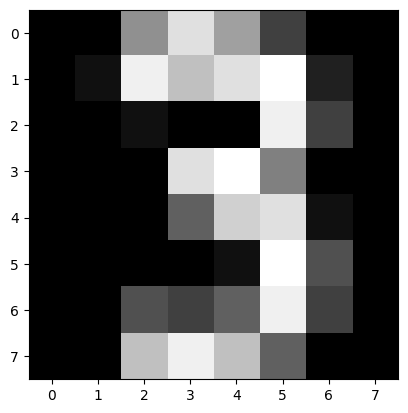

In [7]:
# Plot 8x8 image of first example
plt.imshow(features[3000].reshape(8, 8), cmap="gray")

In [8]:
net = torch.nn.Sequential(
    torch.nn.Linear(feature_size, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 10),
    torch.nn.Softmax(dim=1)
)

n_epochs = 1000
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()
batch_size = 128

# Load data into DataLoader for batching
dataset = torch.utils.data.TensorDataset(features, labels.squeeze().long())
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Train the network
for epoch in range(n_epochs):
    for batch_features, batch_labels in dataloader:
        optimizer.zero_grad()
        outputs = net(batch_features)
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# Quickly test accuracy on the training set
with torch.no_grad():
    outputs = net(features)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == labels.squeeze().long()).float().mean()
    print(f"Training accuracy: {accuracy.item() * 100:.2f}%")

Epoch 0, Loss: 2.30159592628479
Epoch 100, Loss: 2.295654058456421
Epoch 200, Loss: 2.2640221118927
Epoch 300, Loss: 2.0643367767333984
Epoch 400, Loss: 1.7960151433944702
Epoch 500, Loss: 1.6282174587249756
Epoch 600, Loss: 1.547577977180481
Epoch 700, Loss: 1.5324324369430542
Epoch 800, Loss: 1.5351133346557617
Epoch 900, Loss: 1.4980263710021973
Training accuracy: 96.63%


In [12]:
# Export the dataset into C++ header + source files

header_filename = "Dataset.hpp"
source_filename = "Dataset.cpp"
header_template_filename = header_filename + "_template"
source_template_filename = source_filename + "_template"

feature_size_key = r"%FEATURE_SIZE%"
label_size_key = r"%LABEL_SIZE%"
num_examples_key = r"%NUM_EXAMPLES%"
data_type_key = r"%DATA_TYPE%"
features_key = r"%FEATURES%"
labels_key = r"%LABELS%"

# Generate the C++ header file
with open(header_template_filename, "r") as f:
    header_template = f.read()
    header_content = header_template.replace(feature_size_key, str(feature_size)) \
        .replace(label_size_key, str(int(torch.max(labels) + 1))) \
        .replace(num_examples_key, str(n_examples)) \
        .replace(data_type_key, "float")  # Assuming float for simplicity
    with open(header_filename, "w") as hf:
        hf.write(header_content)

# Generate the C++ source file
with open(source_template_filename, "r") as f:
    source_template = f.read()
    features_array_str = "{\n" + ",\n".join(
        ["{" + ", ".join(f"{v:.6f}f" for v in features[i].tolist()) + "}" for i in range(n_examples)]
    ) + "\n}"
    # Headers need to be converted to one-hot
    labels_array_str = "{\n" + ",\n".join(
        ["{" + ", ".join("1.0f" if j == int(labels[i].item()) else "0.0f" for j in range(10)) + "}" for i in range(n_examples)]
    ) + "\n}"
    source_content = source_template.replace(features_key, features_array_str)
    source_content = source_content.replace(labels_key, labels_array_str)
    with open(source_filename, "w") as sf:
        sf.write(source_content)